# Chapter 5: Advanced Parametric vs The ML Floor (Fast Multi-Ticker Showdown)

This notebook implements the hyper-optimized pipeline to compare the `VIX-Scaled Student-T` baseline against the `WideAndDeep` Neural Network over a rigorous expanding window walk-forward backtest.

We measure:
1. **CRPS (Sharpness)**: Lower is better.
2. **Block K-S Failure Rate (Calibration)**: What percentage of 60-day windows fail the K-S test? (Lower is better).

In [1]:
import warnings
warnings.filterwarnings('ignore')

import sys

from datetime import date
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from density_forecasting.evaluation.metrics import block_ks_test
from density_forecasting.evaluation.metrics import evaluate_forecasts
from density_forecasting.models.neural_networks import generate_montecarlo

# Import our optimized pipeline functions
from density_forecasting.evaluation.fast_pipeline import (
    read_data_features,
    extract_array,
    extract_df_nn,
    run_baseline,
    backtesting_baseline,
    initializate_nn_model,
    run_neural_networks,
    backtesting_neural_networks
)


Loaded intel_openmp/libiomp5md.dll from C:\Users\fe_ma\miniconda3\envs\quant-ai-lab-2\Library\bin\libiomp5md.dll





## 1. Configuration & Multi-Ticker Loop

In [2]:
tickers = ['ARKK', 'USO', 'USDCLP=X', 'BTC-USD', 'SQM-B.SN']
tickers = ['USO', 'SQM-B.SN']
start_date = date(2005, 12, 31)
end_date = date(2025, 12, 31)

columns_linear = ['ret_1_mean', 'ret_1', 'ret_2','ret_3', 'ret_1_std', 'ret_1_kurt', 'ret_1_skew', 'ret_1_mean_st', 'ret_1_std_st', 'vix_ratio', 'VIX']

# columns_deep = ['vix_ratio', 'VIX']
columns_deep = ['vix_ratio']
# columns_deep = []


test_window = 22 * 1
porcentage_train = 0.75

initial_epochs = 1500
model_class = 'WideAndDeep'
# model_class = 'Linear'

lr = 0.02

table_results = []


In [3]:
# # columns_linear
# df_features.columns
# 'volume',
# 'Vol_50_MA'
# df_features


STARTING FAST SHOWDOWN FOR USO
Fetching USO data...
Fetching VIX data...
Expanding Window Walk-Forward (Start Train Size: 3672)...
n_train: 3672
Epoch 000 | NLL Loss: 21.7395
Last epoch: 78, Loss: 2.3591
n_train: 3694
Epoch 000 | NLL Loss: 248.4215
Last epoch: 29, Loss: 26.2493
n_train: 3716
Epoch 000 | NLL Loss: 203.0731
Epoch 100 | NLL Loss: 3.0000
Last epoch: 170, Loss: 2.7491
n_train: 3738
Epoch 000 | NLL Loss: 4.1949
Last epoch: 2, Loss: 4.1821
n_train: 3760
Epoch 000 | NLL Loss: 2.6001
Last epoch: 1, Loss: 2.6015
n_train: 3782
Epoch 000 | NLL Loss: 2.7257
Last epoch: 7, Loss: 2.6135
n_train: 3804
Epoch 000 | NLL Loss: 2.5978
Last epoch: 2, Loss: 2.6096
n_train: 3826
Epoch 000 | NLL Loss: 2.8423
Last epoch: 6, Loss: 2.7772
n_train: 3848
Epoch 000 | NLL Loss: 33.5500
Epoch 100 | NLL Loss: 14.9367
Epoch 199 | NLL Loss: 2.5191
Last epoch: 199, Loss: 2.5191
n_train: 3870
Epoch 000 | NLL Loss: 120.0394
Last epoch: 81, Loss: 2.4926
n_train: 3892
Epoch 000 | NLL Loss: 326.3242
Epoch 100

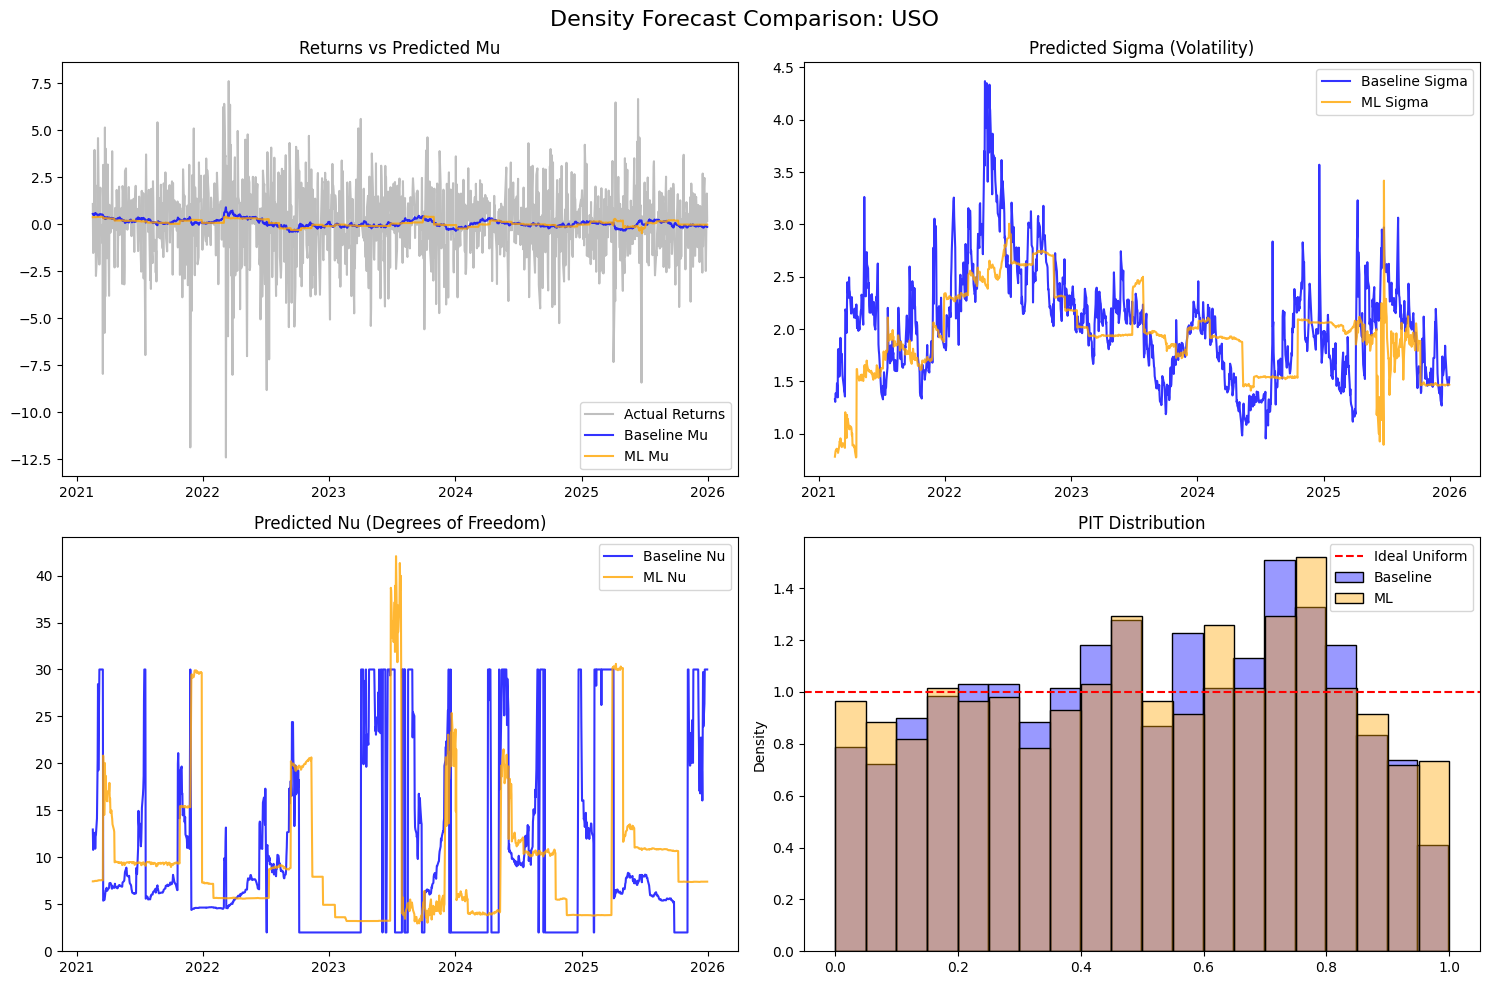


STARTING FAST SHOWDOWN FOR SQM-B.SN
Fetching SQM-B.SN data...
Fetching VIX data...
Expanding Window Walk-Forward (Start Train Size: 3827)...
n_train: 3827
Epoch 000 | NLL Loss: 34.5339
Epoch 100 | NLL Loss: 3.4040
Last epoch: 121, Loss: 2.7672
n_train: 3849
Epoch 000 | NLL Loss: 190.4897
Epoch 100 | NLL Loss: 2.6173
Last epoch: 142, Loss: 2.3988
n_train: 3871
Epoch 000 | NLL Loss: 2.4549
Last epoch: 8, Loss: 2.4181
n_train: 3893
Epoch 000 | NLL Loss: 95.5493
Last epoch: 99, Loss: 2.3540
n_train: 3915
Epoch 000 | NLL Loss: 51.8281
Epoch 100 | NLL Loss: 2.6024
Last epoch: 130, Loss: 2.5114
n_train: 3937
Epoch 000 | NLL Loss: 2.5931
Last epoch: 4, Loss: 2.5660
n_train: 3959
Epoch 000 | NLL Loss: 2.5347
Last epoch: 4, Loss: 2.5129
n_train: 3981
Epoch 000 | NLL Loss: 11.8930
Epoch 100 | NLL Loss: 4.5744
Epoch 199 | NLL Loss: 3.0693
Last epoch: 199, Loss: 3.0693
n_train: 4003
Epoch 000 | NLL Loss: 358.8533
Last epoch: 1, Loss: 358.7091
n_train: 4025
Epoch 000 | NLL Loss: 3.0988
Last epoch: 

In [ ]:
for ticker in tickers:
    print(f"\n{'='*50}")
    print(f"STARTING FAST SHOWDOWN FOR {ticker}")
    print(f"{'='*50}")
    
    # Setup Data
    df_features = read_data_features(ticker, start_date, end_date, window_size_long=22*3)
    columns_linear = list(df_features.columns)
    columns_linear.remove("returns")
    columns_linear.remove('volume')
    columns_linear.remove('Vol_50_MA')
    columns_linear.remove('VIX')
    columns_linear.remove('vix_ratio')
    
    # print(ticker)
    # print(df_features.head())
    dates_test = []
    pred_mu_result = {'baseline': [], 'neural-network': []}
    pred_sigma_result = {'baseline': [], 'neural-network': []}
    pred_nu_result = {'baseline': [], 'neural-network': []}
    pit_values_result = {'baseline': [], 'neural-network': []}
    
    n_train = int(porcentage_train * len(df_features))
    current_epochs = initial_epochs
    cold_start = True
    last_optimal_beta = 0.5
    
    # Initialize NN once per ticker
    train_step, model = initializate_nn_model(columns_linear, model_class, lr, columns_deep=columns_deep)
    
    print(f"Expanding Window Walk-Forward (Start Train Size: {n_train})...")
    
    while n_train < len(df_features):
        print(f'n_train: {n_train}, {(100 * n_train / len(df_features)):.2f}')
        df_features_train = df_features.iloc[:n_train]
        df_X_linear_train, df_X_deep_train, df_y_train = extract_df_nn(df_features_train, columns_linear, columns_deep)
        # 1. FIT: Calculate mean and std ONLY on the training data
        train_linear_mean = df_X_linear_train.mean()
        train_linear_std = df_X_linear_train.std()
        
        # 2. TRANSFORM TRAIN: Apply the scaler to the training data
        df_X_linear_train = (df_X_linear_train - train_linear_mean) / train_linear_std

        if len(columns_deep) > 0:
            train_deep_mean = df_X_deep_train.mean()
            train_deep_std = df_X_deep_train.std()
            df_X_deep_train = (df_X_deep_train - train_deep_mean) / train_deep_std
        
        # print(df_X_linear_train.head())
        # print(len(df_X_linear_train))
        # train_linear_mean, train_deep_mean = df_X_linear_train.mean(), df_X_deep_train.mean()
        # train_linear_std, train_deep_std = df_X_linear_train.std(), df_X_deep_train.std()

        # 3. TRANSFORM TEST: Apply the EXACT SAME Train scaler to the test data
        # test_df[features_to_normalize] = (test_df[features_to_normalize] - train_mean) / train_std

        # train_std = train_df[features_to_normalize].std()

        # train_std = train_df[features_to_normalize].std()

        df_features_test = df_features.iloc[n_train:n_train + test_window]
        df_X_linear_test, df_X_deep_test, df_y_test = extract_df_nn(df_features_test, columns_linear, columns_deep)
        df_X_linear_test = (df_X_linear_test - train_linear_mean) / train_linear_std
        
        if len(columns_deep) > 0:
            df_X_deep_train = (df_X_deep_train - train_deep_mean) / train_deep_std
        # We need this to check if there are any days to test
        if len(df_features_test) == 0:
            break

        dates_test.append(df_features_test.index)

        # Baseline
        data_train = extract_array(df_features_train, df_y_train)
        optimal_beta = run_baseline(data_train, last_optimal_beta, cold_start)
        last_optimal_beta = optimal_beta
        
        data_prior = {}
        for key, values in data_train.items():
            data_prior[key] = [data_train[key][-1]]
        baseline_prior = backtesting_baseline(data_prior, optimal_beta)
        prior_data = {'mu': np.mean(baseline_prior['mu']), 'sigma': np.mean(baseline_prior['sigma']), 'nu': np.mean(baseline_prior['nu'])}

        data_test = extract_array(df_features_test, df_y_test)
        baseline_results = backtesting_baseline(data_test, optimal_beta)

        pred_mu_result['baseline'].append(baseline_results['mu'])
        pred_sigma_result['baseline'].append(baseline_results['sigma'])
        pred_nu_result['baseline'].append(baseline_results['nu'])
        pit_values_result['baseline'].append(baseline_results['pit_values'])

        # Neural Network
        # prior_data = {'mu': np.mean(baseline_results['mu']), 'sigma': np.mean(baseline_results['sigma']), 'nu': baseline_results['nu']}
        # run_neural_networks(df_X_linear_train, df_X_deep_train, df_y_train, current_epochs, train_step, prior_data, verbose=False)
        run_neural_networks(df_X_linear_train, df_X_deep_train, df_y_train, current_epochs, train_step, prior_data, verbose=True)
        
        if cold_start:
            current_epochs = 200
            # current_epochs = current_epochs // 3
            cold_start = False

        neural_networks_results = backtesting_neural_networks(
            tf.convert_to_tensor(df_X_linear_test.to_numpy(), dtype=tf.float32), 
            tf.convert_to_tensor(df_X_deep_test.to_numpy(), dtype=tf.float32) if df_X_deep_test is not None else None, 
            tf.convert_to_tensor(df_y_test.to_numpy(), dtype=tf.float32), 
            model
        )

        pred_mu_result['neural-network'].append(neural_networks_results['mu'])
        pred_sigma_result['neural-network'].append(neural_networks_results['sigma'])
        pred_nu_result['neural-network'].append(neural_networks_results['nu'])
        pit_values_result['neural-network'].append(neural_networks_results['pit_values'])

        n_train += test_window

    # Combine Results for this Ticker
    dates_test_total = pd.Index(np.concatenate(dates_test))
    actual_returns = df_features['returns'].loc[dates_test_total]
    
    # Helper to compute metrics
    def calculate_metrics(model_name):
        mu_total = np.concatenate(pred_mu_result[model_name])
        sigma_total = np.concatenate(pred_sigma_result[model_name])
        nu_total = np.concatenate(pred_nu_result[model_name])
        pit_total = np.concatenate(pit_values_result[model_name])
        
        # Monte carlo for CRPS
        ensembles = generate_montecarlo(mu_total, sigma_total, nu_total, n_samples=1000)
        df_eval = evaluate_forecasts(actual_returns, ensembles)
        
        crps = df_eval['CRPS'].mean()
        
        # Block KS
        df_pit_total = pd.DataFrame(pit_total, index=df_eval.index).iloc[22:]
        df_ks = block_ks_test(df_pit_total, block_size=22*6, alpha=0.05)
        ks_fail = (df_ks['Status'] == '❌ FAILED').mean() if len(df_ks) > 0 else 1.0
        
        return crps, ks_fail
        
    crps_base, ks_base = calculate_metrics('baseline')
    crps_nn, ks_nn = calculate_metrics('neural-network')
    
    table_results.append({
        'Ticker': ticker,
        'CRPS_Vix_StudentT': crps_base,
        'CRPS_WideDeep_ML': crps_nn,
        'CRPS_Winner': 'ML' if crps_nn < crps_base else 'VIX-StudentT',
        'KS_Fail_Vix_StudentT': ks_base,
        'KS_Fail_WideDeep_ML': ks_nn,
        'KS_Winner': 'ML' if ks_nn < ks_base else ('Tie' if ks_nn == ks_base else 'VIX-StudentT')
    })
    
    print(f"Metrics -> Baseline CRPS: {crps_base:.4f} | ML CRPS: {crps_nn:.4f}")

    # --- BLOCK PLOT (2x2) ---
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(f"Density Forecast Comparison: {ticker}", fontsize=16)

    mu_base = np.concatenate(pred_mu_result['baseline'])
    mu_nn = np.concatenate(pred_mu_result['neural-network'])
    axes[0, 0].plot(dates_test_total, actual_returns, label='Actual Returns', alpha=0.5, color='gray')
    axes[0, 0].plot(dates_test_total, mu_base, label='Baseline Mu', alpha=0.8, color='blue')
    axes[0, 0].plot(dates_test_total, mu_nn, label='ML Mu', alpha=0.8, color='orange')
    axes[0, 0].set_title('Returns vs Predicted Mu')
    axes[0, 0].legend()

    sigma_base = np.concatenate(pred_sigma_result['baseline'])
    sigma_nn = np.concatenate(pred_sigma_result['neural-network'])
    axes[0, 1].plot(dates_test_total, sigma_base, label='Baseline Sigma', alpha=0.8, color='blue')
    axes[0, 1].plot(dates_test_total, sigma_nn, label='ML Sigma', alpha=0.8, color='orange')
    axes[0, 1].set_title('Predicted Sigma (Volatility)')
    axes[0, 1].legend()

    nu_base = np.concatenate(pred_nu_result['baseline'])
    nu_nn = np.concatenate(pred_nu_result['neural-network'])
    axes[1, 0].plot(dates_test_total, nu_base, label='Baseline Nu', alpha=0.8, color='blue')
    axes[1, 0].plot(dates_test_total, nu_nn, label='ML Nu', alpha=0.8, color='orange')
    axes[1, 0].set_title('Predicted Nu (Degrees of Freedom)')
    axes[1, 0].legend()

    pit_base = np.concatenate(pit_values_result['baseline'])
    pit_nn = np.concatenate(pit_values_result['neural-network'])
    sns.histplot(pit_base, bins=20, color='blue', alpha=0.4, label='Baseline', ax=axes[1, 1], stat='density')
    sns.histplot(pit_nn, bins=20, color='orange', alpha=0.4, label='ML', ax=axes[1, 1], stat='density')
    axes[1, 1].axhline(1.0, color='red', linestyle='--', label='Ideal Uniform')
    axes[1, 1].set_title('PIT Distribution')
    axes[1, 1].legend()

    plt.tight_layout()
    plt.show()
        # Export timeseries data for this specific ticker
    import os
    import json
    
    output_dir = '../outputs'
    os.makedirs(output_dir, exist_ok=True)
    ts_file = f'{output_dir}/df_timeseries.json'
    
    ts_data_all = {}
    if os.path.exists(ts_file):
        try:
            with open(ts_file, 'r') as f:
                ts_data_all = json.load(f)
        except Exception:
            pass
            
    ts_data_all[ticker] = {
        "dates": dates_test_total.astype(str).tolist(),
        "actual_returns": actual_returns.tolist(),
        "sigma_base": sigma_base.tolist(),
        "sigma_nn": sigma_nn.tolist()
    }
    
    with open(ts_file, 'w') as f:
        json.dump(ts_data_all, f)

## 2. Final Comparison Table

In [ ]:
df_results = pd.DataFrame(table_results)
df_results.set_index('Ticker', inplace=True)

# Format for pretty display
df_results['KS_Fail_Vix_StudentT'] = df_results['KS_Fail_Vix_StudentT'].map(lambda x: f"{x:.1%}")
df_results['KS_Fail_WideDeep_ML'] = df_results['KS_Fail_WideDeep_ML'].map(lambda x: f"{x:.1%}")
df_results['CRPS_Vix_StudentT'] = df_results['CRPS_Vix_StudentT'].map(lambda x: f"{x:.4f}")
df_results['CRPS_WideDeep_ML'] = df_results['CRPS_WideDeep_ML'].map(lambda x: f"{x:.4f}")

display(df_results)


,CRPS_Vix_StudentT,CRPS_WideDeep_ML,CRPS_Winner,KS_Fail_Vix_StudentT,KS_Fail_WideDeep_ML,KS_Winner
Ticker,,,,,,
USO,1.1416,1.1177,ML,0.0%,28.6%,VIX-StudentT
SQM-B.SN,1.5732,1.5187,ML,0.0%,42.9%,VIX-StudentT


In [ ]:
import os
output_dir = '../outputs'
os.makedirs(output_dir, exist_ok=True)
df_results.to_csv(f'{output_dir}/showdown_results.csv')
df_results.to_json(f'{output_dir}/showdown_results.json', orient='index')
print(f'Results saved to {output_dir}')


Results saved to ../outputs
